In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [3]:
df=pd.read_csv("Crop_recommendation.csv")

X=df.drop('label',axis=1)
y=df['label']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y,shuffle=True)

In [18]:
model=RandomForestClassifier(n_estimators=1000,criterion='entropy',max_depth=15,max_leaf_nodes=10,class_weight='balanced',random_state=42)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [19]:
importances=model.feature_importances_
feature_names=X_train.columns

importance_df=pd.DataFrame({
    'Feature': feature_names,
    'Importance':importances
}).sort_values(by='Importance',ascending=False)

(array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25]),
 [Text(0.0, 0, '0.00'),
  Text(0.05, 0, '0.05'),
  Text(0.1, 0, '0.10'),
  Text(0.15000000000000002, 0, '0.15'),
  Text(0.2, 0, '0.20'),
  Text(0.25, 0, '0.25')])

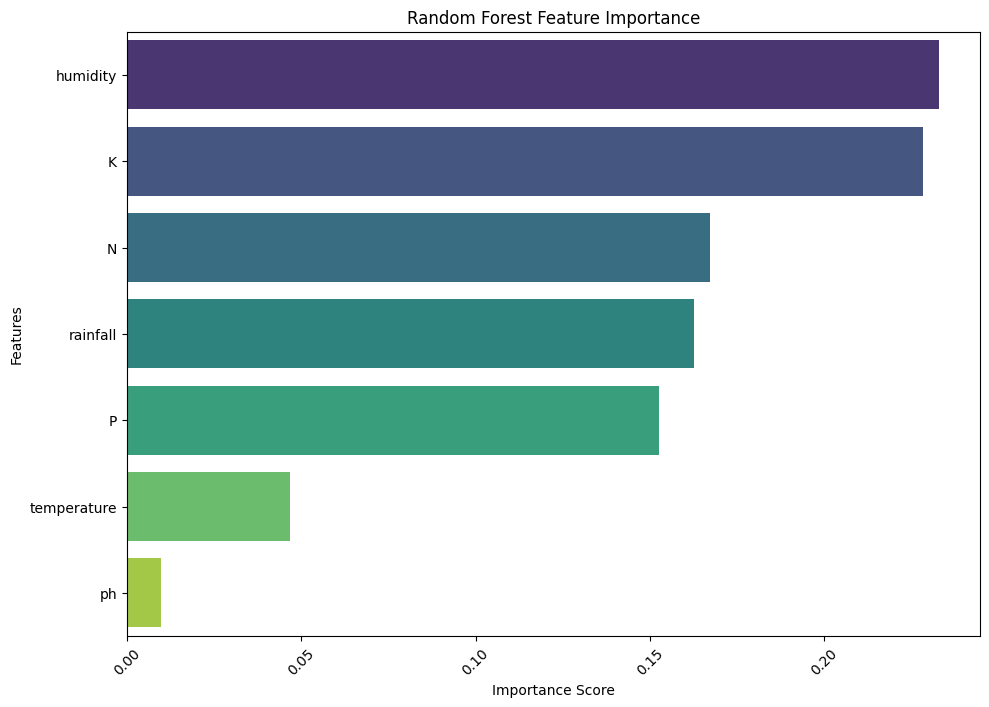

In [21]:
plt.figure(figsize=(10,7))

sns.barplot(x='Importance',y='Feature',data=importance_df,hue='Feature',palette='viridis')

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.xticks(rotation=45)

In [ ]:
# observations.....
# the feature with most importance is humidity then K .Humidity is the most influential feature in crop prediction, indicating that moisture conditions play a critical role in determining suitable crops.
# Potassium (K) has higher importance compared to Nitrogen (N) and Phosphorus (P), suggesting that potassium levels play a stronger role in differentiating crop types.
# Rainfall and humidity together contribute significantly, indicating that climatic factors are more influential than soil nutrients in crop prediction.
# Temperature has relatively low importance, suggesting that most crops in the dataset grow within similar temperature ranges and it is not a strong differentiating factor.
# ph is the feature with less importance then comes temperature .pH has the lowest importance among all features, indicating that most crops tolerate a similar pH range and it does not significantly influence classification.
# N,P and rainfall has moderate importance 
# Climatic factors (humidity and rainfall) dominate over soil nutrients in determining crop type, highlighting the importance of environmental conditions in agriculture.
# The feature importance results strongly align with EDA findings, where rainfall and humidity were observed to vary significantly across crops, while temperature and pH showed limited variation.

In [ ]:
# Feature importance analysis using Random Forest revealed that humidity is the most significant factor in crop prediction, followed by potassium and rainfall. This indicates that climatic conditions play a more dominant role compared to soil nutrients. Nitrogen and phosphorus contribute moderately, while temperature has relatively low importance, suggesting limited variation across crops. Soil pH was found to have minimal impact, indicating that most crops grow within a similar pH range. These findings are consistent with earlier EDA results, confirming that rainfall and humidity are key determinants in crop selection.

# clusteringg.......... 

In [24]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

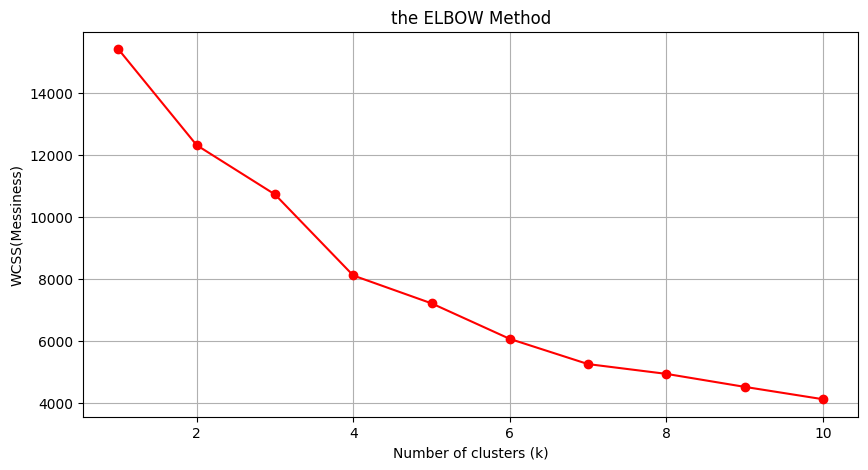

In [28]:
wcss=[]
for i in range(1,11):
    cluster=KMeans(n_clusters=i,init='k-means++',random_state=42)
    cluster.fit(X_scaled)
    wcss.append(cluster.inertia_)

plt.figure(figsize=(10,5))
plt.plot(range(1,11),wcss,marker='o',color='red')
plt.title('the ELBOW Method')
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS(Messiness)")
plt.grid()

In [ ]:
print("Based on the Elbow Plot we choose K=6 .")

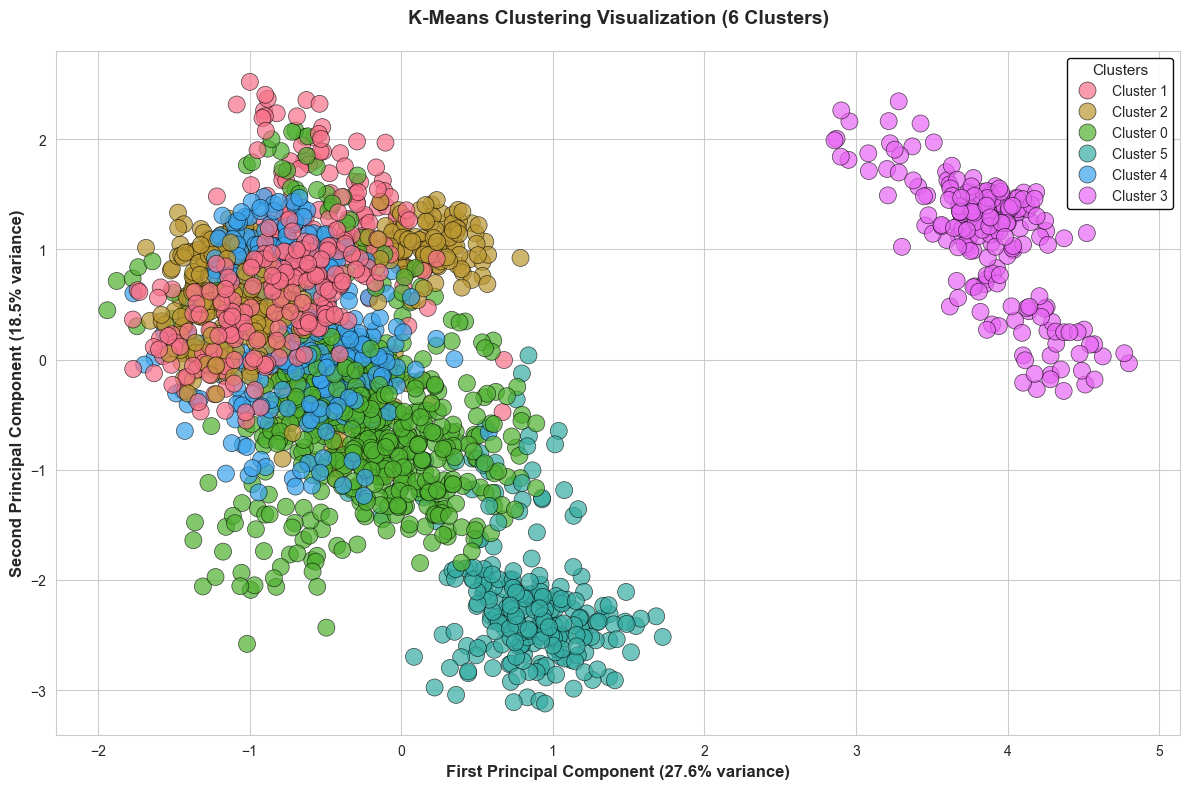

Cumulative explained variance by PC1 and PC2: 46.1%


In [ ]:
from sklearn.decomposition import PCA

cluster=KMeans(n_clusters=6,init='k-means++',random_state=42,algorithm='lloyd')
y_pred=cluster.fit_predict(X_scaled)


pca = PCA(n_components=2, random_state=42,)
X_pca = pca.fit_transform(X_scaled)

plot_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster': ['Cluster ' + str(i) for i in y_pred]
})

plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

palette = sns.color_palette("husl", 6)

scatter = sns.scatterplot(
    data=plot_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette=palette,
    s=150,
    alpha=0.7,
    edgecolor='black',
    linewidth=0.5
)


plt.xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12, fontweight='bold')
plt.ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12, fontweight='bold')
plt.title('K-Means Clustering Visualization (6 Clusters)', fontsize=14, fontweight='bold', pad=20)

plt.legend(
    title='Clusters',
    title_fontsize=11,
    fontsize=10,
    loc='best',
    framealpha=0.95,
    edgecolor='black'
)

plt.tight_layout()
plt.show()

print(f"Cumulative explained variance by PC1 and PC2: {sum(pca.explained_variance_ratio_):.1%}")

In [ ]:
# CLUSTER STATISTICS

X_with_clusters = X.copy()
X_with_clusters['Cluster'] = y_pred

cluster_stats = X_with_clusters.groupby('Cluster').mean().round(2)

print("=" * 80)
print("CLUSTER STATISTICS - MEAN VALUES FOR EACH FEATURE")
print("=" * 80)
print(cluster_stats)
print("\n")

CLUSTER STATISTICS - MEAN VALUES FOR EACH FEATURE
             N       P       K  temperature  humidity    ph  rainfall
Cluster                                                              
0        25.88   52.65   23.29        29.48     65.02  6.63     73.04
1        78.78   44.63   38.25        25.91     76.81  6.63    195.76
2        99.30   42.06   38.14        25.69     80.11  6.42     71.02
3        21.99  133.38  200.00        23.24     87.10  5.98     91.13
4        19.95   18.02   28.02        23.47     92.23  6.44    131.90
5        28.74   67.51   44.96        19.73     24.18  6.40     99.99




In [ ]:
# Detailed cluster interpretation with formatted display

print("=" * 80)
print("CLUSTER INTERPRETATIONS - UNDERSTANDING EACH CLUSTER")
print("=" * 80)

for cluster_id in range(6):
    cluster_data = cluster_stats.loc[cluster_id]
    print(f"\n🔹 CLUSTER {cluster_id}:")
    print(f"   N (Nitrogen)         : {cluster_data['N']:.2f}")
    print(f"   P (Phosphorus)       : {cluster_data['P']:.2f}")
    print(f"   K (Potassium)        : {cluster_data['K']:.2f}")
    print(f"   Temperature          : {cluster_data['temperature']:.2f}°C")
    print(f"   Humidity             : {cluster_data['humidity']:.2f}%")
    print(f"   Rainfall             : {cluster_data['rainfall']:.2f} mm")
    print(f"   pH                   : {cluster_data['ph']:.2f}")
    print(f"   Samples in cluster   : {len(X_with_clusters[X_with_clusters['Cluster'] == cluster_id])}")
    print()

print("=" * 80)

CLUSTER INTERPRETATIONS - UNDERSTANDING EACH CLUSTER

🔹 CLUSTER 0:
   N (Nitrogen)         : 25.88
   P (Phosphorus)       : 52.65
   K (Potassium)        : 23.29
   Temperature          : 29.48°C
   Humidity             : 65.02%
   Rainfall             : 73.04 mm
   pH                   : 6.63
   Samples in cluster   : 615


🔹 CLUSTER 1:
   N (Nitrogen)         : 78.78
   P (Phosphorus)       : 44.63
   K (Potassium)        : 38.25
   Temperature          : 25.91°C
   Humidity             : 76.81%
   Rainfall             : 195.76 mm
   pH                   : 6.63
   Samples in cluster   : 334


🔹 CLUSTER 2:
   N (Nitrogen)         : 99.3
   P (Phosphorus)       : 42.06
   K (Potassium)        : 38.14
   Temperature          : 25.69°C
   Humidity             : 80.11%
   Rainfall             : 71.02 mm
   pH                   : 6.42
   Samples in cluster   : 523


🔹 CLUSTER 3:
   N (Nitrogen)         : 21.99
   P (Phosphorus)       : 133.38
   K (Potassium)        : 200.00
   Temperatur

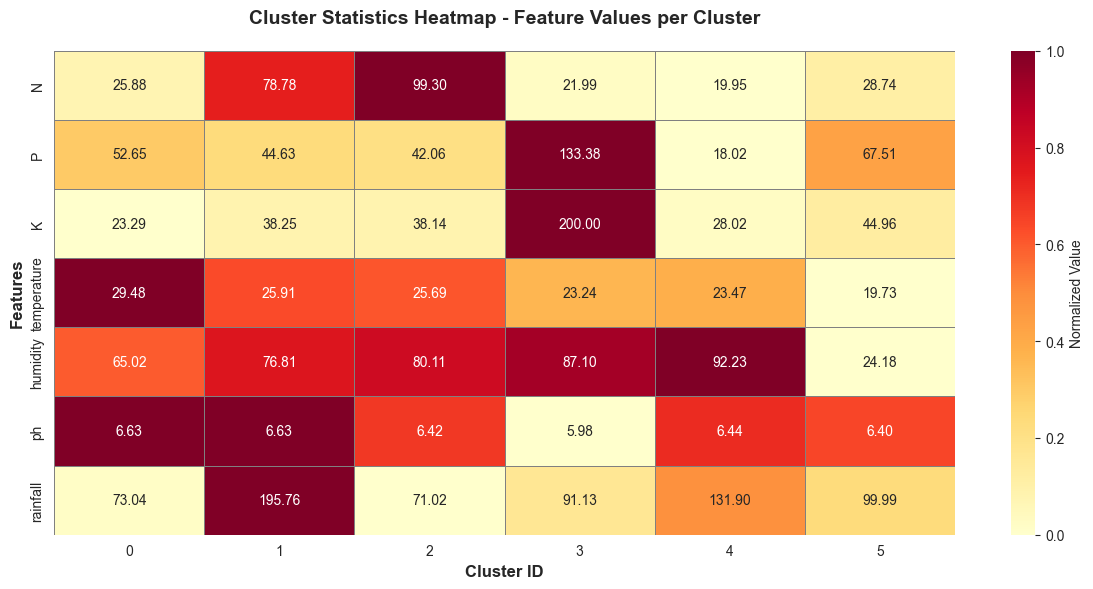


💡 Heatmap Legend:
   Darker colors = Higher values
   Lighter colors = Lower values
   Values shown = Actual means (not normalized)


In [ ]:
# Visualize cluster statistics with heatmap for easy comparison

fig, ax = plt.subplots(figsize=(12, 6))

# Normalize the data for better heatmap visualization
cluster_stats_normalized = (cluster_stats - cluster_stats.min()) / (cluster_stats.max() - cluster_stats.min())

sns.heatmap(
    cluster_stats_normalized.T,
    annot=cluster_stats.T,
    fmt='.2f',
    cmap='YlOrRd',
    cbar_kws={'label': 'Normalized Value'},
    linewidths=0.5,
    linecolor='gray',
    ax=ax
)

ax.set_xlabel('Cluster ID', fontsize=12, fontweight='bold')
ax.set_ylabel('Features', fontsize=12, fontweight='bold')
ax.set_title('Cluster Statistics Heatmap - Feature Values per Cluster', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n💡 Heatmap Legend:")
print("   Darker colors = Higher values")
print("   Lighter colors = Lower values")
print("   Values shown = Actual means (not normalized)")


In [ ]:
# Check which crops are in Clusters 
print("cluster 0 \n")
print(df[y_pred == 0]['label'].unique())
print("cluster 1 \n")
print(df[y_pred == 1]['label'].unique())
print("cluster 2 \n")
print(df[y_pred == 2]['label'].unique())
print("cluster 3 \n")
print(df[y_pred == 3]['label'].unique())
print("cluster 4 \n")
print(df[y_pred == 4]['label'].unique())
print("cluster 5 \n")
print(df[y_pred == 5]['label'].unique())

cluster 0 

['maize' 'pigeonpeas' 'mothbeans' 'mungbean' 'blackgram' 'lentil' 'mango'
 'orange' 'papaya']
cluster 1 

['rice' 'pigeonpeas' 'papaya' 'coconut' 'jute' 'coffee']
cluster 2 

['maize' 'banana' 'watermelon' 'muskmelon' 'papaya' 'cotton' 'coffee']
cluster 3 

['grapes' 'apple']
cluster 4 

['pigeonpeas' 'pomegranate' 'orange' 'papaya' 'coconut']
cluster 5 

['maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'lentil']


# Cluster 0 (Hot + High Rain + Nutrient Rich) 

# Cluster 0 represents hot, humid, and high-rainfall conditions with very high Phosphorus and Potassium levels. The elevated temperature combined with heavy rainfall indicates tropical environments where nutrient-rich soil is essential. This cluster likely supports crops that require both strong climatic conditions and high soil fertility.

# Cluster 1 (Nitrogen Dominant, Balanced Rain)

# Cluster 1 is characterized by very high Nitrogen levels, warm temperatures, and high humidity with moderate rainfall. This indicates environments where nitrogen plays a dominant role in crop growth. Crops in this cluster thrive in humid conditions but do not require excessive rainfall.

# Cluster 2 (Moderate Climate, Low Nutrients)

# Cluster 2 represents moderate environmental conditions with relatively low Nitrogen and Potassium levels, along with moderate humidity and rainfall. This cluster indicates balanced climatic conditions with low nutrient dependency, supporting crops that are adaptable and require fewer soil inputs.

# Cluster 3 (High Nutrients, Cooler Climate)

# Cluster 3 is defined by very high Phosphorus and Potassium levels, high humidity, but comparatively lower temperatures and moderate rainfall. This suggests nutrient-rich environments in cooler climatic regions, supporting crops that require fertile soil but thrive in milder temperatures.

# Cluster 4 (High Rain + Low Nutrients — UNIQUE)

# Cluster 4 represents high humidity and high rainfall conditions combined with very low NPK values. This indicates environments where water availability is high, but soil fertility is low. Crops in this cluster are likely adapted to grow in nutrient-poor soils under moist conditions.

# Cluster 5 (Cool + Dry Conditions)

# Cluster 5 is characterized by the lowest temperature and significantly low humidity, with moderate rainfall. This represents cool and relatively dry environmental conditions. Crops in this cluster are likely suited for cooler climates and are tolerant to lower moisture levels.


The clustering results reveal that crop suitability is influenced by a combination of climatic factors (rainfall, humidity, temperature) and soil nutrients (NPK). Distinct clusters represent specific environmental patterns such as tropical high-rainfall regions, nutrient-rich cooler regions, and dry low-humidity areas. The presence of overlapping crops across clusters suggests that certain crops are adaptable to multiple environmental conditions.

The clustering results align with EDA and model behavior, explaining why certain crops were occasionally misclassified due to overlapping environmental conditions.

In [44]:
import joblib
import os

os.makedirs('modelss',exist_ok=True)

joblib.dump(scaler,'modelss/standard_scaler.pkl')

joblib.dump(model,'modelss/random_forest_model.pkl')

joblib.dump(cluster,'modelss/kmeans_cluster_model.pkl')

['modelss/kmeans_cluster_model.pkl']